For full credit, do not program in any constants yourself. Use the <tt>scipy</tt> versions, which the cell above will import for you. Use <tt>numpy</tt> arrays instead of lists.

### Spacetime coordinate axes

Recall that in PHYS 207, you were often asked to plot displacement as a function of time. For example, for a baseball thrown directly upward you would plot $y(t)$, and for a block on a horizontal spring you would plot $x(t)$. Here we will examine how the displacement and time axes "scissor together" at relativistic speeds.

The convention in relativity is to reverse the axes: $ct$ is vertical and $x$ is horizontal. Time moves forward from the bottom to the top of the plot:

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

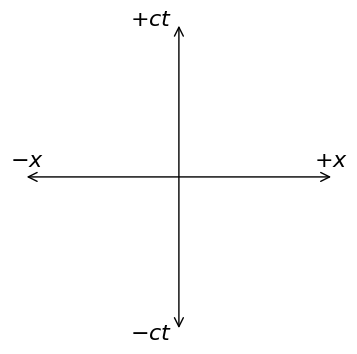

In [2]:
plt.figure(figsize=(4,4))
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.annotate(text='', xy=(-1,0), xytext=(1,0), arrowprops=dict(arrowstyle='<->'))
plt.annotate(text='', xy=(0,-1), xytext=(0,1), arrowprops=dict(arrowstyle='<->'))
plt.text(0.98, 0.04, r"$+x$", horizontalalignment='center', verticalalignment='bottom')
plt.text(-0.98, 0.04, r"$-x$", horizontalalignment='center', verticalalignment='bottom')
plt.text(-0.04, 1.02, r"$+ct$", horizontalalignment='right', verticalalignment='center')
plt.text(-0.04, -1.02, r"$-ct$", horizontalalignment='right', verticalalignment='center')
plt.axis('off')

Imagine that frame $K^{\prime}$ is moving in the $+x$ direction at speed $v$ relative to frame $K$. You are at rest in frame $K$. Let's figure out how the set of $(x^{\prime}, ct^{\prime})$ axes would look to you when the frames' origins $O$ and $O^{\prime}$ coincide.

<ol>
    <li>Use the fact that $x^{\prime} = 0$ on the $ct^{\prime}$ axis to define a line $ct(x)$ in frame $K$ that follows the $ct^{\prime}$ axis. Write a function that computes points on the line. $v$ will be one of your function inputs.</li>
</ol>

In [3]:
def ct_prime_axis(x: float, v: float) -> float:
    return constants.speed_of_light * x / v

<ol start=2>
    <li>Use the fact that $ct^{\prime} = 0$ on the $x^{\prime}$ axis to define a line $ct(x)$ that traces the $x^{\prime}$ axis in frame $K$. Write a second function that computes points on this line.</li>
</ol>

In [4]:
def x_prime_axis(x: float, v: float) -> float:
    return v * x / constants.speed_of_light

<ol start=3>
    <li>The code below creates a figure with centered $(x, ct)$ axes that have range $(-10^{10}, 10^{10})$ m. We are using $ct$ instead of just $t$ on our vertical axis so that both axes have the same units. Use your functions from problems 1 and 2 to overplot the $ct^{\prime}$ and $x^{\prime}$ axes <strong>as a function of $x$</strong> for $v = 0.2c$. Make your $ct^{\prime}$ and $x^{\prime}$ axes red, and label them in red. Also add black labels to the $(x, ct)$ axes giving the coordinate name ($x$ or $ct$) and the units.</li>
</ol>

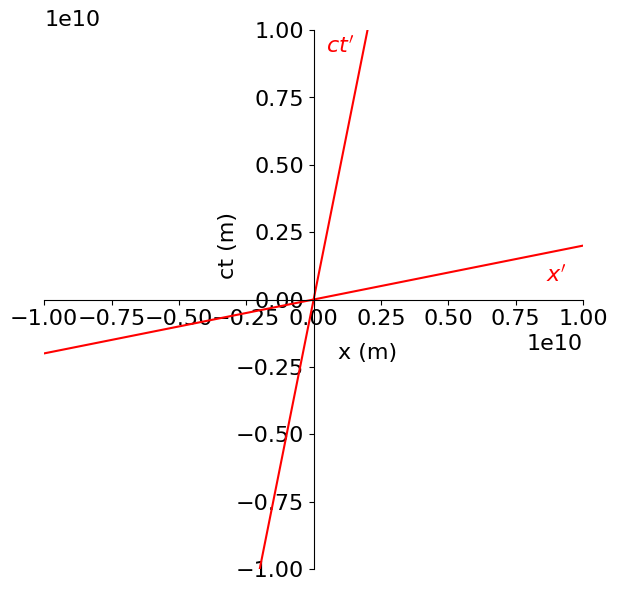

In [5]:
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(7,7))

# YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
v = 0.2 * constants.speed_of_light

ct_prime = ct_prime_axis(x, v)
ax.plot(x, ct_prime, color="red")

x_prime = x_prime_axis(x, v)
ax.plot(x, x_prime, color="red")

# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# YOUR CODE HERE: Use ax.text() to add RED labels to the ct' and x' axes below
ax.text(.1e10, .9e10, r"$ct'$", horizontalalignment='center', verticalalignment='bottom', color="red")
ax.text(.9e10, .05e10, r"$x'$", horizontalalignment='center', verticalalignment='bottom', color="red")

# Label axes
ax.set_xlabel("x (m)")
ax.xaxis.set_label_coords(.6, .42)
ax.set_ylabel("ct (m)")
ax.yaxis.set_label_coords(.36, .6)

<ol start=4>
    <li>Make a figure that plots $ct^{\prime}$ and $x^{\prime}$ axes for $v = 0.25c$, $v = 0.5c$, and $v = 0.75c$. Use different colors for each pair of axes. Make a legend that shows which value of $v$ corresponds to each color. Label the $(x, ct)$ axes and add units.</li>
</ol>

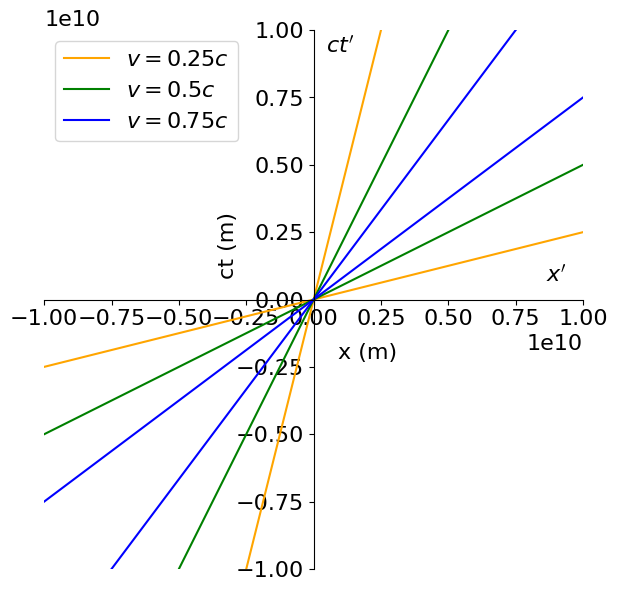

In [6]:
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(7,7))

# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# Label axes
ax.set_xlabel("x (m)")
ax.xaxis.set_label_coords(.6, .42)
ax.set_ylabel("ct (m)")
ax.yaxis.set_label_coords(.36, .6)

ax.text(.1e10, .9e10, r"$ct'$", horizontalalignment='center', verticalalignment='bottom')
ax.text(.9e10, .05e10, r"$x'$", horizontalalignment='center', verticalalignment='bottom')

colors = ["orange", "green", "blue"]
fractions = [0.25, 0.5, 0.75]
labels = [r"$v=0.25c$", r"$v=0.5c$", r"$v=0.75c$"]
for i in range(3):
    # YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
    v = fractions[i] * constants.speed_of_light
    
    ct_prime = ct_prime_axis(x, v)
    ax.plot(x, ct_prime, color=colors[i], label=labels[i])
    
    x_prime = x_prime_axis(x, v)
    ax.plot(x, x_prime, color=colors[i])
ax.legend()

<ol start=5>
    <li>Connect your graph from problem 4 with the discussion of world lines in Chapter 2 of your textbook. What kind of world line do your $(x^{\prime}, ct^{\prime})$ axes approach as $v \rightarrow c$? Create a similar plot to problem 4, but this time plot $(x^{\prime}, ct^{\prime})$ axes for $v = 0.5, 0.75, 0.875, 0.9375$. To illustrate the concept of taking a limit as $v \rightarrow c$, make each set of $( x^{\prime}, ct^{\prime})$ axes a successively darker shade of gray. Plot the limiting world line in black. Add a legend to show which value of $v$ corresponds to which shade of gray. You may find it helpful to specify line colors like this: <tt>color='0.7'</tt>.</li>
</ol>

As v approaches c, we get the world line representing a light-like trajectory, which separates time-like (slower than light) from space-like (faster than light).

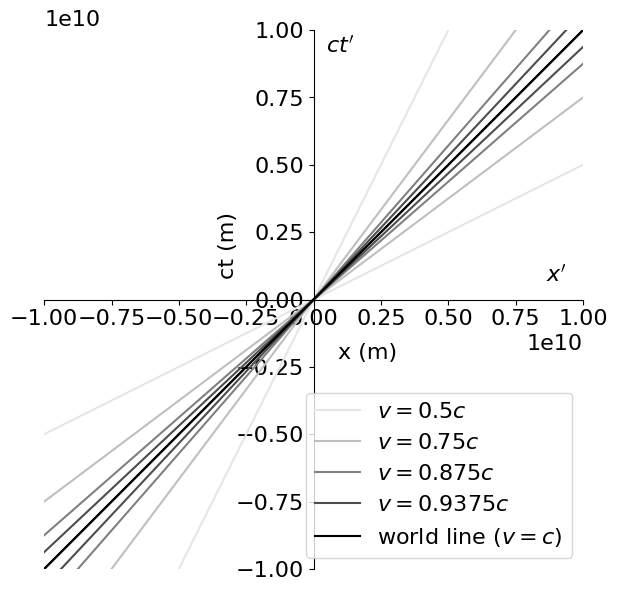

In [7]:
# Set up an array of independent variables x that spans (-1e10, 1e10) m
x = np.linspace(0, 2e10, num=201, endpoint=True) - 1e10

# Make a figure
fig, ax = plt.subplots(figsize=(7,7))

# Move the left and bottom "spines" (borders of the plot) to the center
# This makes a math textbook-like set of (x,ct) axes instead of a box around the plot
ax.spines['left'].set_position(('data', 0))
ax.spines['bottom'].set_position(('data', 0))

# Take out the top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Make the two axes have the same scale
ax.set_aspect('equal')

# Set the axes ranges
ax.set_xlim([-1e10, 1e10])
ax.set_ylim([-1e10, 1e10])

# Label axes
ax.set_xlabel("x (m)")
ax.xaxis.set_label_coords(.6, .42)
ax.set_ylabel("ct (m)")
ax.yaxis.set_label_coords(.36, .6)

ax.text(.1e10, .9e10, r"$ct'$", horizontalalignment='center', verticalalignment='bottom')
ax.text(.9e10, .05e10, r"$x'$", horizontalalignment='center', verticalalignment='bottom')

colors = ["0.9", "0.75", "0.5", "0.3", "0"]
fractions = [0.5, 0.75, 0.875, 0.9375, 1]
labels = [r"$v=0.5c$", r"$v=0.75c$", r"$v=0.875c$", r"$v=0.9375c$", r"world line ($v=c$)"]
for i in range(5):
    # YOUR CODE HERE: Use ax.plot() to plot the ct' and x' axes below
    v = fractions[i] * constants.speed_of_light
    
    ct_prime = ct_prime_axis(x, v)
    ax.plot(x, ct_prime, color=colors[i], label=labels[i])
    
    x_prime = x_prime_axis(x, v)
    ax.plot(x, x_prime, color=colors[i])
ax.legend(loc="lower right")

#### More HIPE

From within HIPE, open and run the script called <strong><tt>scanmap_Extended_emission_JyPScanam_58Eri_green.py</tt></strong> which you will find in <strong>Computer Assignent 2</strong> on Canvas. The script will download two scan maps of the debris disk surrounding the star <a href="https://simbad.cds.unistra.fr/simbad/sim-id?Ident=58+Eri&NbIdent=1&Radius=2&Radius.unit=arcmin&submit=submit+id">58 Eri</a> and combine them to make an image. Take a screenshot of the image that appears in the HIPE pop-up window and display it in the code cell below.

Note: You may have to make a Herschel Science Archive account and log into it from within HIPE.

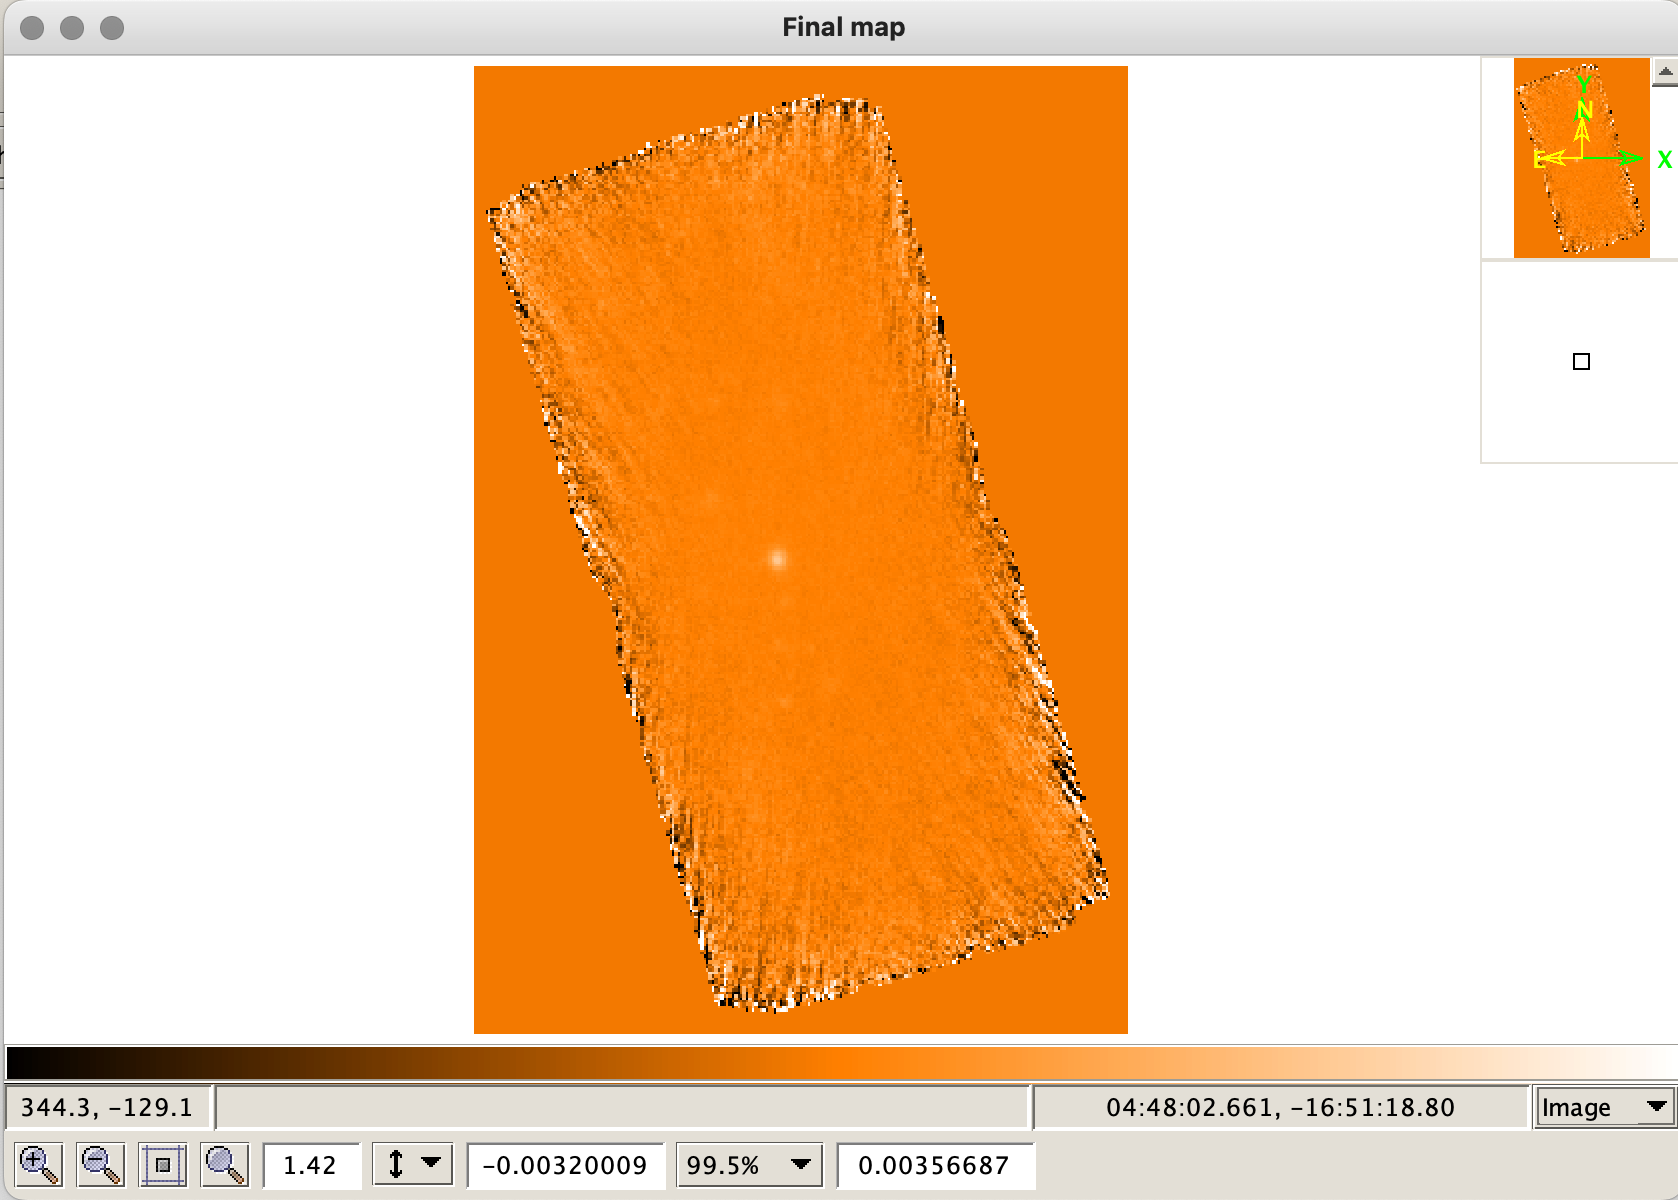

In [8]:
from IPython.display import Image, display

display(Image(filename='emission_scanmap_58_Eri.png'))